# Approach 1: Climate Clash Flags

Flagging every warm-vs-cool team matchup that occurs in a warm venue. No Elo or probability filters — pure climate geography.


## 1. Setup & Data

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from collections import Counter

sns.set_theme(style='whitegrid', font_scale=1.05)
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

ml = pd.read_csv('../data/2026_matchup_list_enriched.csv')
fixtures = pd.read_csv('../data/2026_group_stage.csv')
elo = pd.read_csv('../data/elo_current_2026.csv').set_index('Team')['Elo_Current']

# Venue temperature assignment (same logic as before)
team_to_group = {}
for _, row in fixtures.iterrows():
    team_to_group[row['Home_Team']] = row['Group']
    team_to_group[row['Away_Team']] = row['Group']

TOP_HALF = set('ABCDEF')
BOTTOM_HALF = set('GHIJKL')
PARAMS = {'same_group': (27, 23), 'same_half': (22, 23), 'opposite': (27, 23)}

if 'Venue_Temp_C' not in ml.columns or ml['Venue_Temp_C'].isna().all():
    def est_temp(a, b):
        ga = team_to_group.get(a, ''); gb = team_to_group.get(b, '')
        if not ga or not gb: return 23
        if ga == gb: return sum(PARAMS['same_group']) / 2
        if (ga in TOP_HALF) == (gb in TOP_HALF): return sum(PARAMS['same_half']) / 2
        return sum(PARAMS['opposite']) / 2
    ml['Venue_Temp_C'] = ml.apply(lambda r: est_temp(r['Team_A'], r['Team_B']), axis=1)

VENUE_THRESHOLD = 23  # Hot venue threshold
ml['Warm_Venue'] = (ml['Venue_Temp_C'] > VENUE_THRESHOLD).astype(int)
ml['Is_Climate_Clash'] = (ml['Warm_A'] != ml['Warm_B']).astype(int)

# Climate clash in warm venue
ml['Climate_Clash_Warm_Venue'] = ((ml['Is_Climate_Clash'] == 1) & (ml['Warm_Venue'] == 1)).astype(int)

# Counts
clash = ml[ml['Is_Climate_Clash'] == 1]
warm_venue = ml[ml['Warm_Venue'] == 1]
clash_warm_venue = ml[ml['Climate_Clash_Warm_Venue'] == 1]

print(f'Total knock-out matchups: {len(ml)}')
print(f'Warm-vs-cool clashes: {len(clash)} ({len(clash)/len(ml)*100:.0f}%)')
print(f'Warm venue matchups: {len(warm_venue)} ({len(warm_venue)/len(ml)*100:.0f}%)')
print(f'Climate clash IN warm venue: {len(clash_warm_venue)} ({len(clash_warm_venue)/len(ml)*100:.0f}%)')
print(f'Venue temp: {ml["Venue_Temp_C"].min():.0f}-{ml["Venue_Temp_C"].max():.0f}C, threshold={VENUE_THRESHOLD}C')

Total knock-out matchups: 1024
Warm-vs-cool clashes: 475 (46%)
Warm venue matchups: 562 (55%)
Climate clash IN warm venue: 257 (25%)
Venue temp: 23-25C, threshold=23C


## 2. Full Enriched Matchup List

In [2]:
pd.set_option('display.max_rows', None)

display = ml[['Team_A', 'Team_B', 'Probability', 'Venue_Temp_C', 'Warm_Venue',
              'Warm_A', 'Warm_B', 'Is_Climate_Clash', 'Climate_Clash_Warm_Venue',
              'Warm_Team', 'Cool_Team', 'Elo_A', 'Elo_B', 'Koppen_A', 'Koppen_B']].copy()
display['Prob %'] = (display['Probability'] * 100).round(2)
display = display.sort_values('Climate_Clash_Warm_Venue', ascending=False)
display.index = range(1, len(display) + 1)
display


,Team_A,Team_B,Probability,Venue_Temp_C,Warm_Venue,Warm_A,Warm_B,Is_Climate_Clash,Climate_Clash_Warm_Venue,Warm_Team,Cool_Team,Elo_A,Elo_B,Koppen_A,Koppen_B,Prob %
1,Australia,England,0.0106,24.75,1,1,0,1,1,Australia,England,1891.0,2083.0,BWh,Cfb,1.06
2,Haiti,Norway,0.0155,24.75,1,1,0,1,1,Haiti,Norway,1661.0,1994.0,Aw,Dfc,1.55
3,Croatia,United States,0.0032,24.75,1,0,1,1,1,United States,Croatia,1979.0,1832.0,Cfb,Cfa,0.32
4,Czech Republic,Iran,0.0165,24.75,1,0,1,1,1,Iran,Czech Republic,1837.0,1893.0,Dfb,BWh,1.65
5,Argentina,Sweden,0.0032,24.75,1,1,0,1,1,Argentina,Sweden,2190.0,1793.0,Cfa,Dfc,0.32
6,Spain,Sweden,0.0070,24.75,1,1,0,1,1,Spain,Sweden,2216.0,1793.0,Csa,Dfc,0.70
7,England,Panama,0.0032,24.75,1,0,1,1,1,Panama,England,2083.0,1831.0,Cfb,Am,0.32
8,Austria,Turkey,0.0448,24.75,1,0,1,1,1,Turkey,Austria,1929.0,1998.0,Dfb,Csa,4.48
9,Bosnia and Herzegovina,Portugal,0.0071,24.75,1,0,1,1,1,Portugal,Bosnia and Herzegovina,1653.0,2049.0,Cfb,Csa,0.71
10,Iran,Netherlands,0.0071,24.75,1,1,0,1,1,Iran,Netherlands,1893.0,2006.0,BWh,Cfb,0.71


## 3. Venue Temperature Distribution (All Matchups)

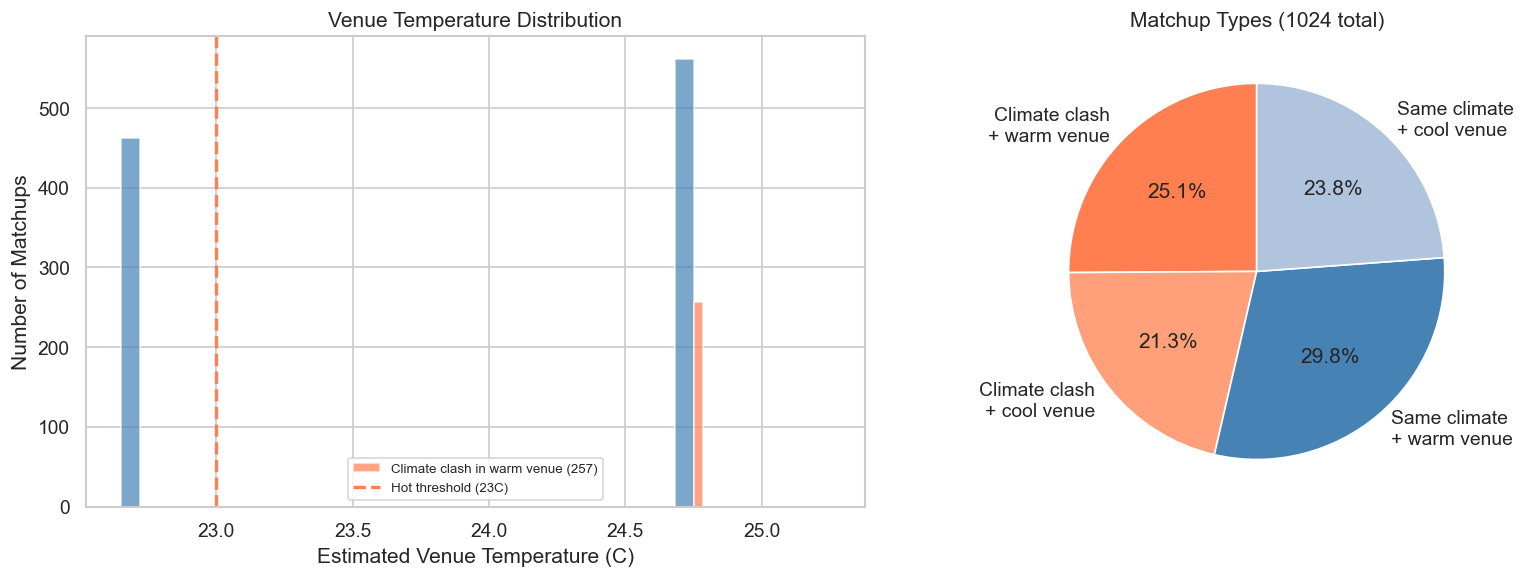

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(ml['Venue_Temp_C'], bins=30, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].hist(clash_warm_venue['Venue_Temp_C'], bins=30, color='coral', edgecolor='white', alpha=0.7,
             label=f'Climate clash in warm venue ({len(clash_warm_venue)})')
axes[0].axvline(x=VENUE_THRESHOLD, color='coral', linestyle='--', linewidth=2, label=f'Hot threshold ({VENUE_THRESHOLD}C)')
axes[0].set_xlabel('Estimated Venue Temperature (C)')
axes[0].set_ylabel('Number of Matchups')
axes[0].set_title('Venue Temperature Distribution')
axes[0].legend(fontsize=8)

# Pie chart of matchups by climate+venue type
types = {
    'Climate clash\n+ warm venue': len(clash_warm_venue),
    'Climate clash\n+ cool venue': len(clash) - len(clash_warm_venue),
    'Same climate\n+ warm venue': len(warm_venue) - len(clash_warm_venue),
    'Same climate\n+ cool venue': len(ml) - len(clash) - len(warm_venue) + len(clash_warm_venue),
}
axes[1].pie(types.values(), labels=types.keys(), autopct='%1.1f%%',
            colors=['coral', 'lightsalmon', 'steelblue', 'lightsteelblue'],
            startangle=90)
axes[1].set_title(f'Matchup Types ({len(ml)} total)')

plt.tight_layout()

## 4. Climate Clashes in Warm Venues — Probability vs Temperature

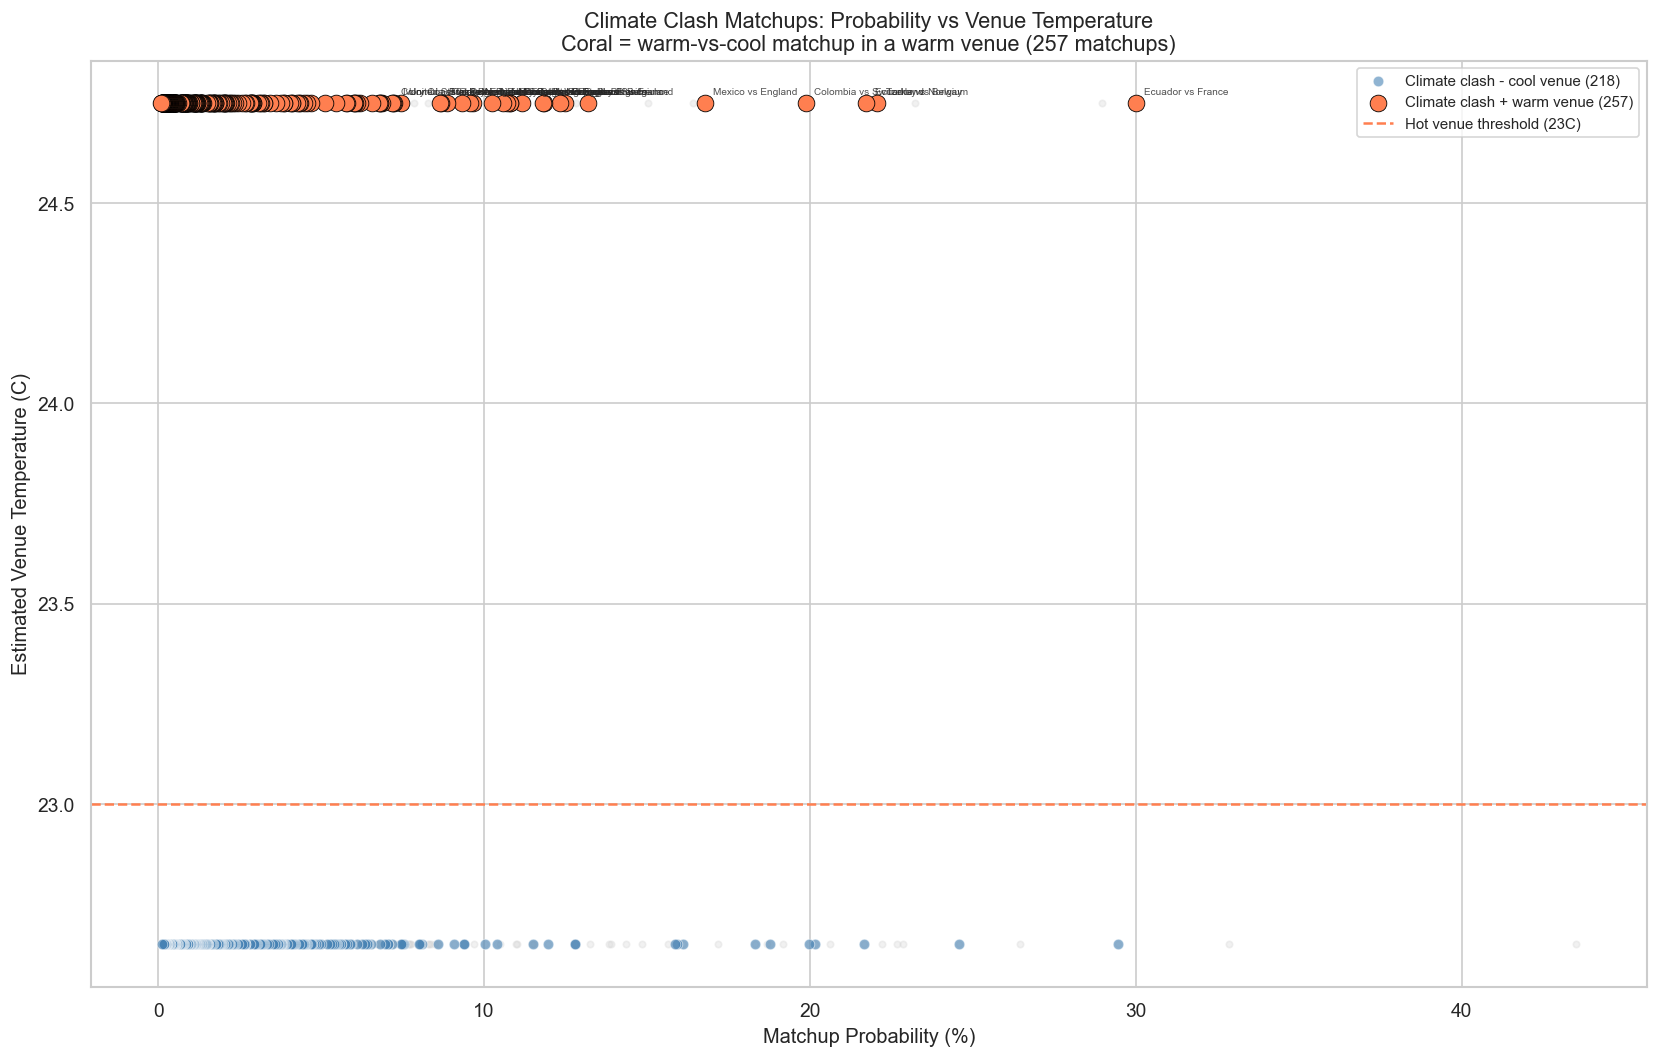

In [4]:
fig, ax = plt.subplots(figsize=(14, 9))

# Background: all matchups
ax.scatter(ml['Probability'] * 100, ml['Venue_Temp_C'],
           c='lightgray', alpha=0.3, s=15, zorder=1)

# All climate clashes
clash_all = ml[ml['Is_Climate_Clash'] == 1]
ax.scatter(clash_all['Probability'] * 100, clash_all['Venue_Temp_C'],
           c='steelblue', alpha=0.6, s=40, edgecolors='white', linewidth=0.5, zorder=2,
           label=f'Climate clash - cool venue ({len(clash_all) - len(clash_warm_venue)})')

# Climate clashes in warm venues (highlighted)
ax.scatter(clash_warm_venue['Probability'] * 100, clash_warm_venue['Venue_Temp_C'],
           c='coral', alpha=1, s=100, edgecolors='black', linewidth=0.5, zorder=3,
           label=f'Climate clash + warm venue ({len(clash_warm_venue)})')

# Annotate top 25 by probability
top25 = clash_warm_venue.nlargest(25, 'Probability')
for _, r in top25.iterrows():
    ax.annotate(f'{r["Warm_Team"]} vs {r["Cool_Team"]}',
                (r['Probability'] * 100, r['Venue_Temp_C']),
                textcoords='offset points', xytext=(5, 5), fontsize=6, alpha=0.8)

ax.axhline(y=VENUE_THRESHOLD, color='coral', linestyle='--', linewidth=1.5,
           label=f'Hot venue threshold ({VENUE_THRESHOLD}C)')

ax.set_xlabel('Matchup Probability (%)', fontsize=12)
ax.set_ylabel('Estimated Venue Temperature (C)', fontsize=12)
ax.set_title(f'Climate Clash Matchups: Probability vs Venue Temperature\n'
             f'Coral = warm-vs-cool matchup in a warm venue ({len(clash_warm_venue)} matchups)',
             fontsize=13)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()

## 5. Top Climate Clashes by Probability

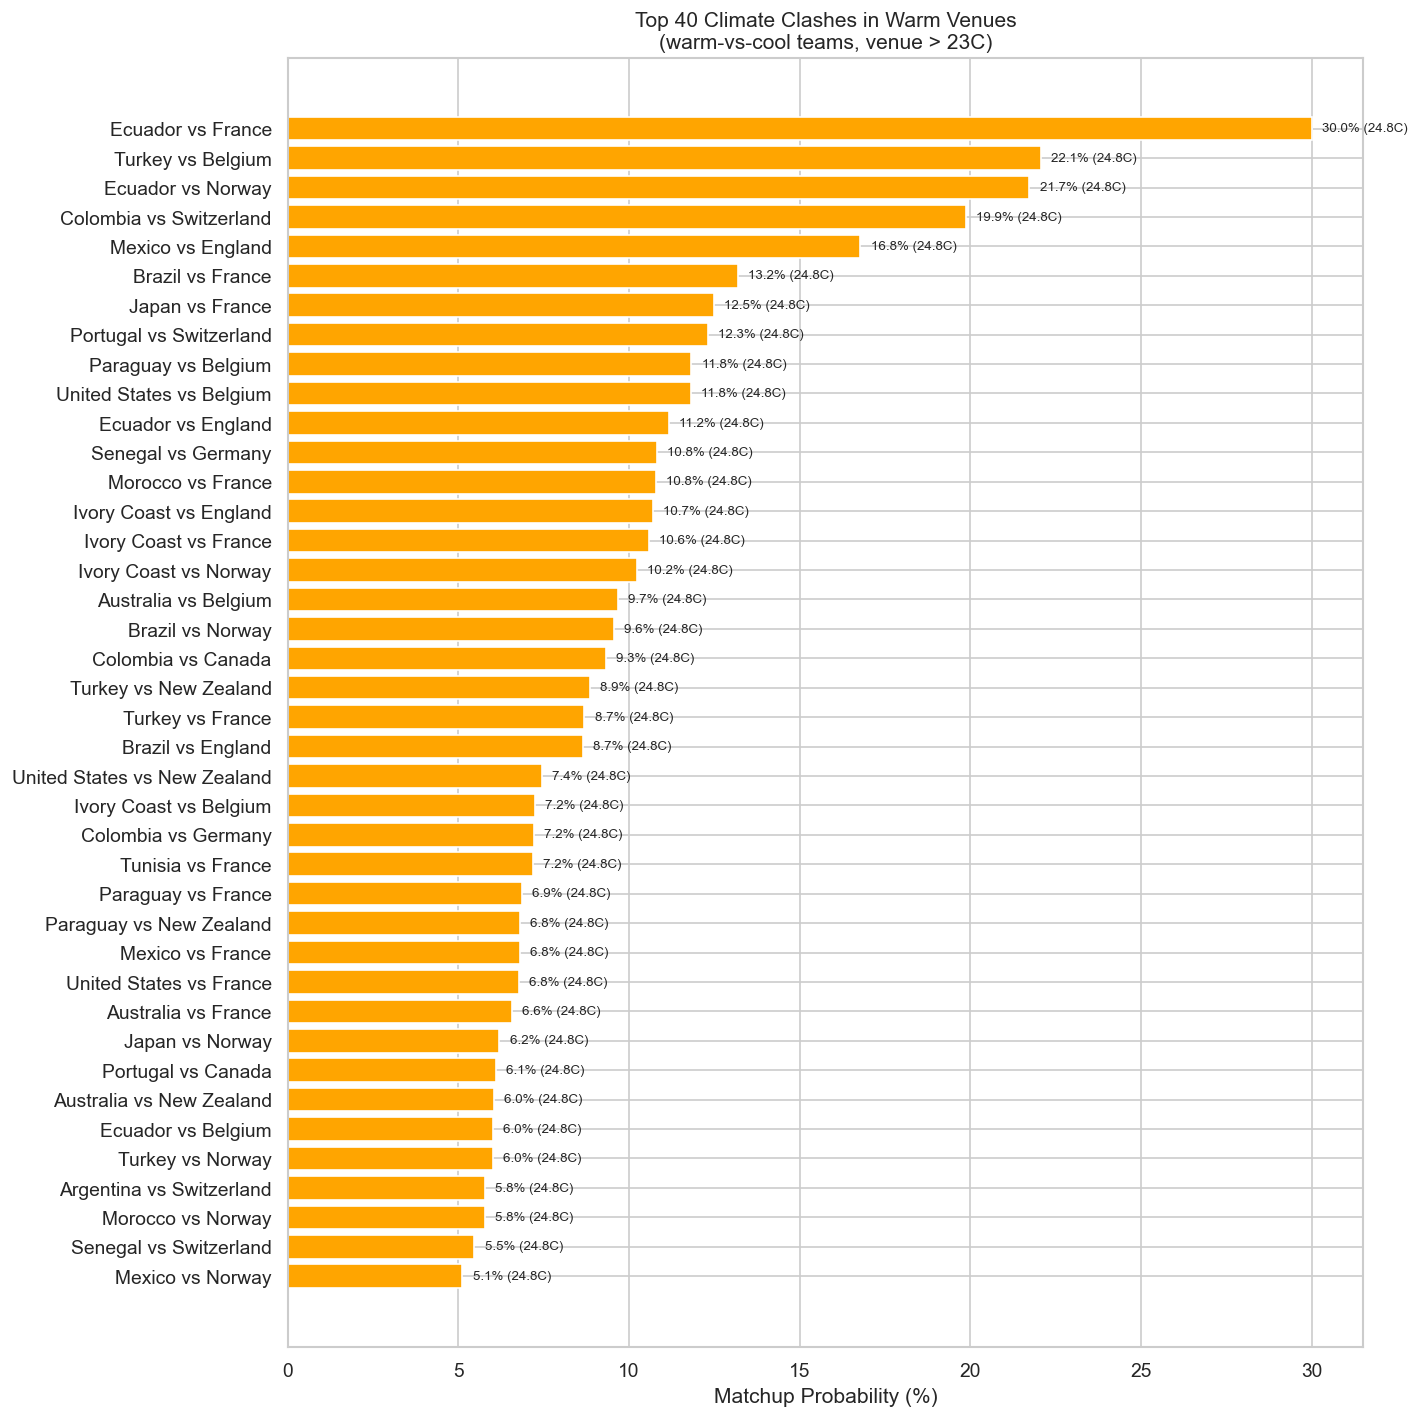

In [5]:
top = clash_warm_venue.nlargest(40, 'Probability').sort_values('Probability')

fig, ax = plt.subplots(figsize=(12, 12))
labels = [f'{r["Warm_Team"]} vs {r["Cool_Team"]}' for _, r in top.iterrows()]
temps = top['Venue_Temp_C'].values
colors_bar = ['coral' if t > VENUE_THRESHOLD + 2 else 'orange' for t in temps]
bars = ax.barh(labels, top['Probability'] * 100, color=colors_bar, edgecolor='white')

for bar, (_, r) in zip(bars, top.iterrows()):
    prob = r['Probability'] * 100
    temp = r['Venue_Temp_C']
    ax.text(prob + 0.3, bar.get_y() + bar.get_height()/2,
            f'{prob:.1f}% ({temp:.1f}C)', va='center', fontsize=8)

ax.set_xlabel('Matchup Probability (%)')
ax.set_title(f'Top 40 Climate Clashes in Warm Venues\n'
             f'(warm-vs-cool teams, venue > {VENUE_THRESHOLD}C)')
plt.tight_layout()

## 6. Team Exposure: Who Faces the Most Climate Clashes?

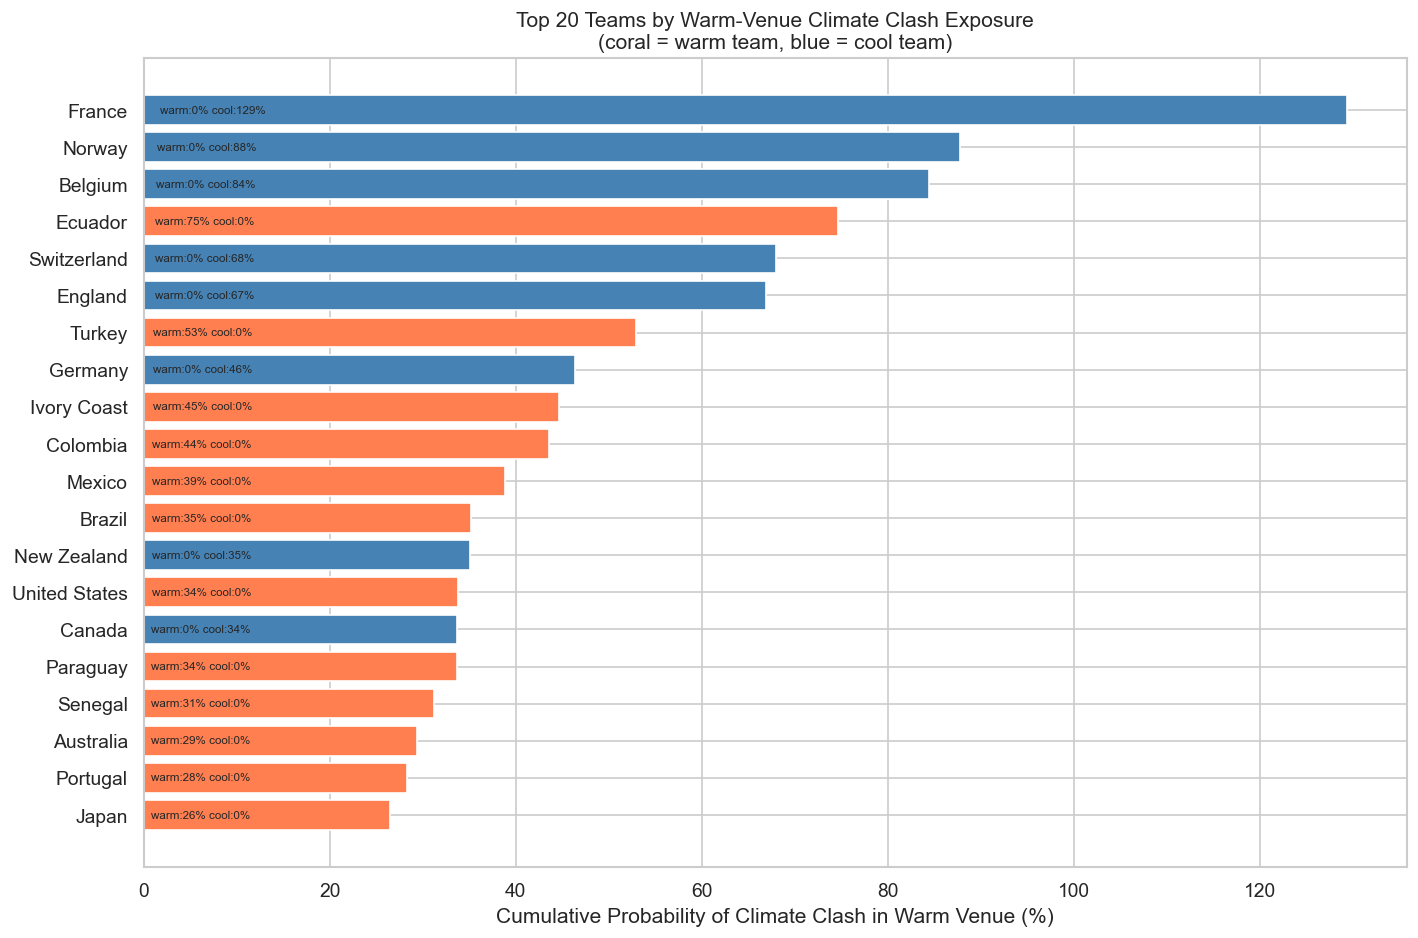

In [6]:
# Cumulative probability of being in a climate clash in a warm venue
warm_team_exposure = Counter()
cool_team_exposure = Counter()

for _, r in clash_warm_venue.iterrows():
    warm_team_exposure[r['Warm_Team']] += r['Probability']
    cool_team_exposure[r['Cool_Team']] += r['Probability']

# Combined exposure (either side)
combined = Counter()
for t, p in warm_team_exposure.items(): combined[t] = combined.get(t, 0) + p
for t, p in cool_team_exposure.items(): combined[t] = combined.get(t, 0) + p

top_exp = combined.most_common(20)

fig, ax = plt.subplots(figsize=(12, 8))
teams_list = [t for t, _ in reversed(top_exp)]
probs_list = [p * 100 for _, p in reversed(top_exp)]
colors_exp = []
for t in teams_list:
    w = warm_team_exposure.get(t, 0)
    c = cool_team_exposure.get(t, 0)
    colors_exp.append('coral' if w > c else 'steelblue')

ax.barh(teams_list, probs_list, color=colors_exp, edgecolor='white')
for i, (team, prob) in enumerate(reversed(top_exp)):
    w = warm_team_exposure.get(team, 0) * 100
    c = cool_team_exposure.get(team, 0) * 100
    ax.text(prob + 0.5, i, f'warm:{w:.0f}% cool:{c:.0f}%', va='center', fontsize=7)

ax.set_xlabel('Cumulative Probability of Climate Clash in Warm Venue (%)')
ax.set_title(f'Top 20 Teams by Warm-Venue Climate Clash Exposure\n(coral = warm team, blue = cool team)')
plt.tight_layout()

## 7. Warm vs Cool Team Heatmap (Warm Venues Only)

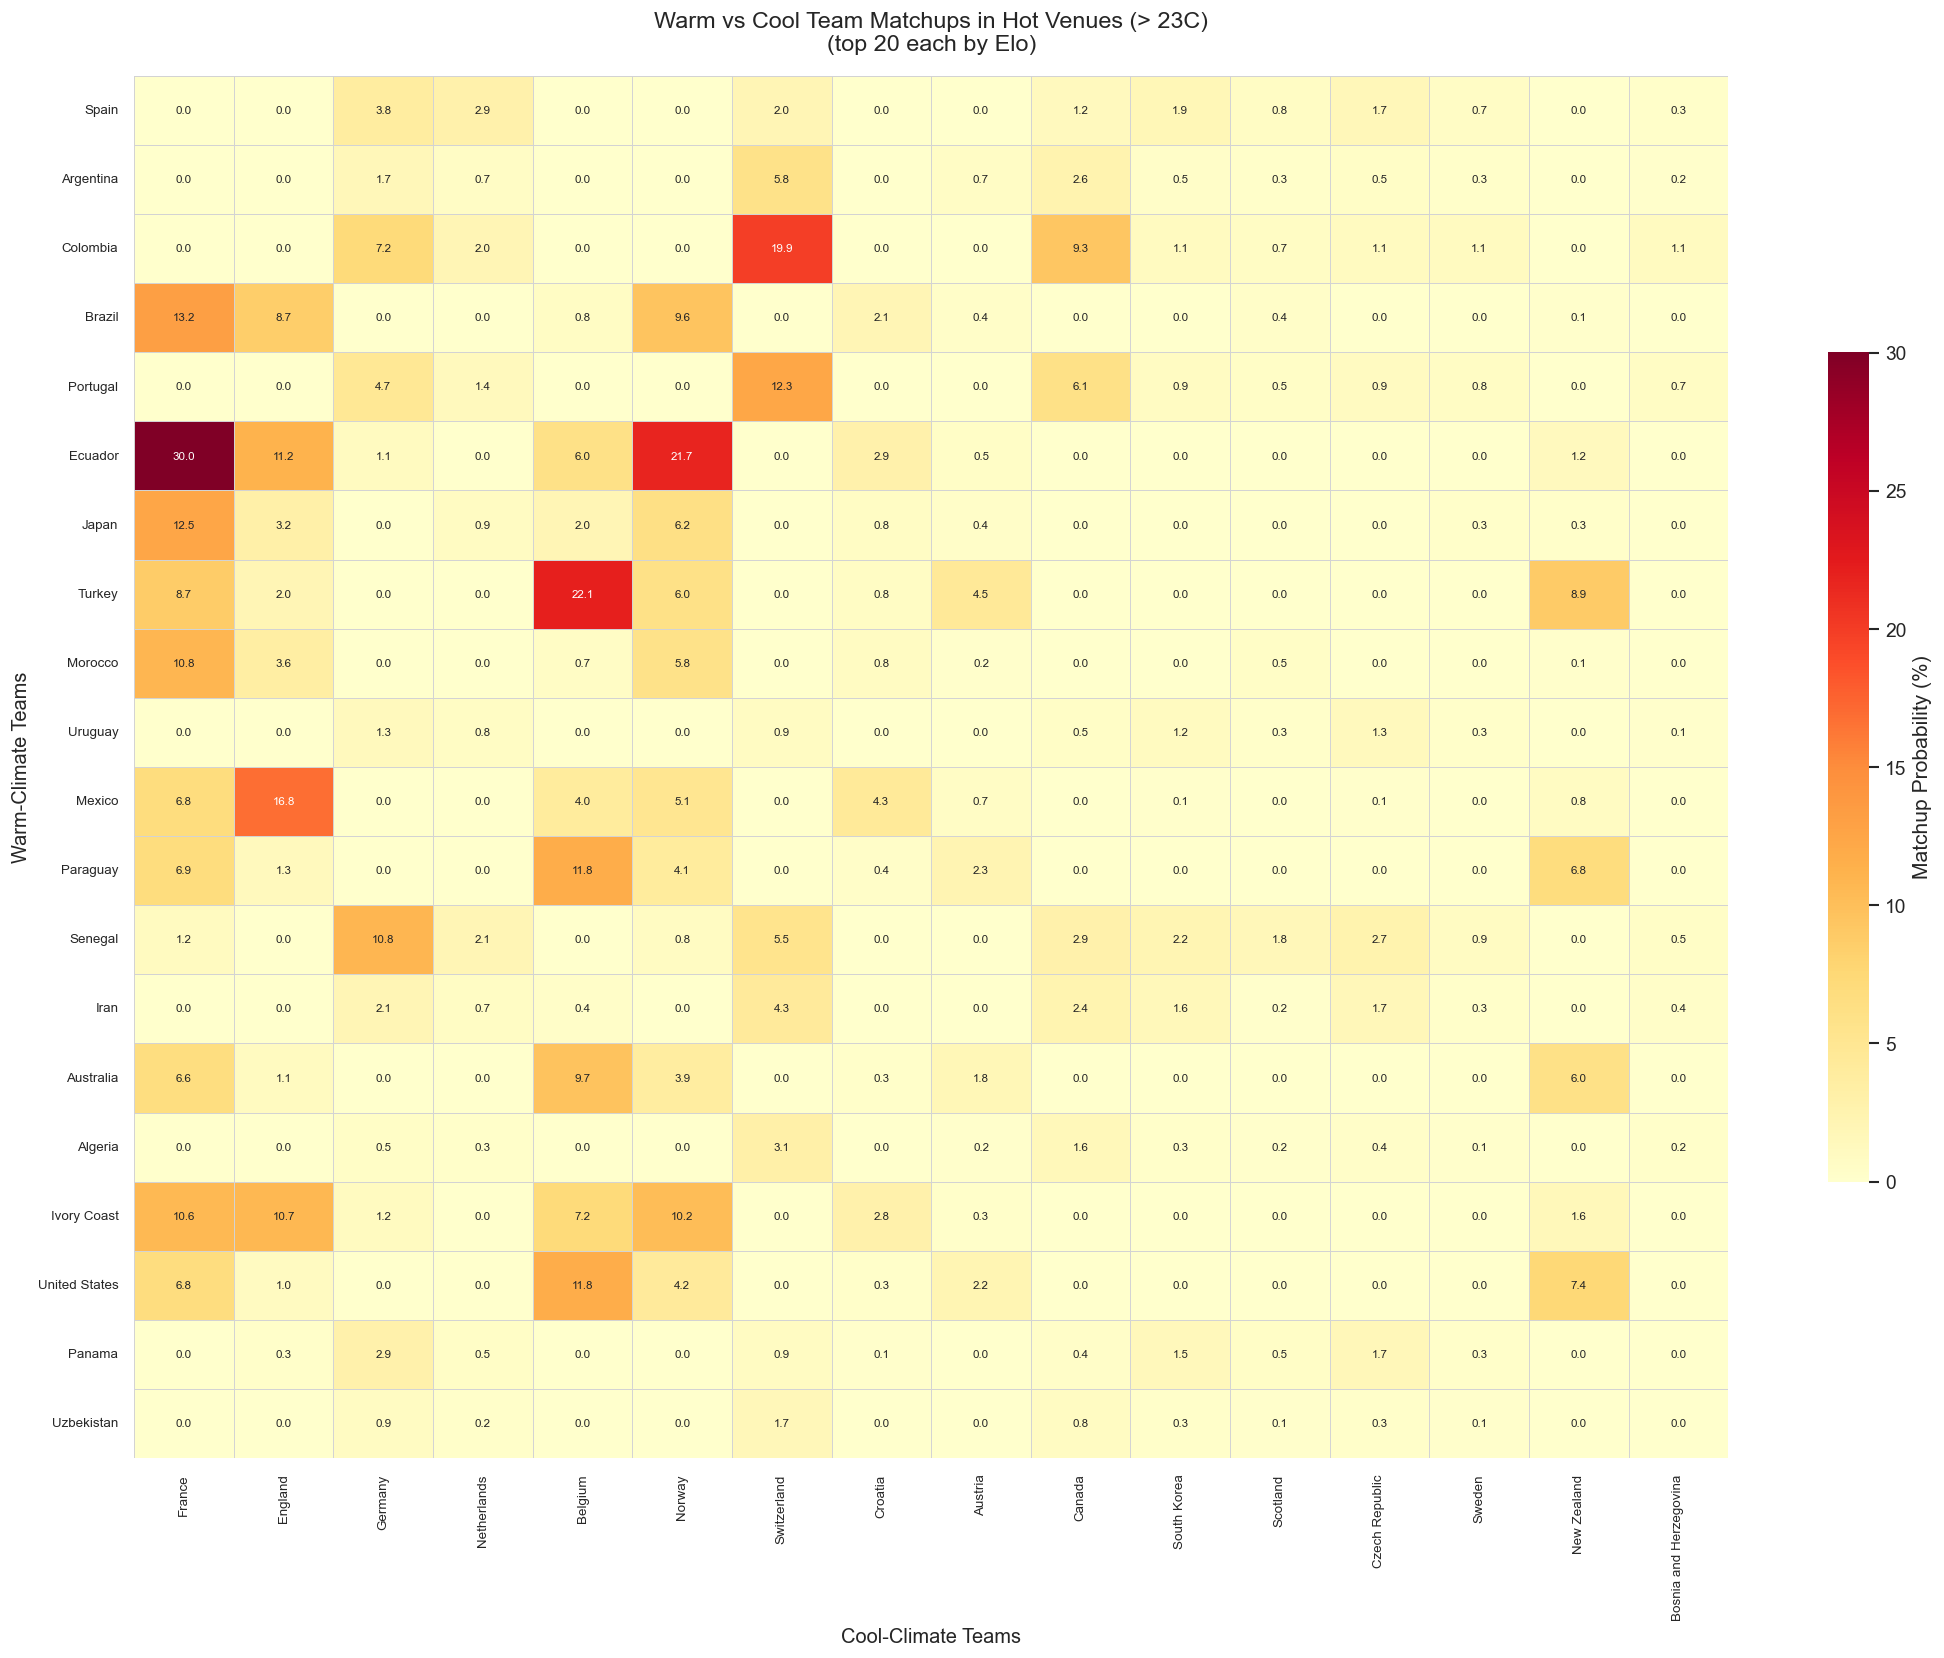

In [7]:
warm_teams = sorted(set(clash_warm_venue['Warm_Team']), key=lambda t: elo.get(t, 0), reverse=True)
cool_teams = sorted(set(clash_warm_venue['Cool_Team']), key=lambda t: elo.get(t, 0), reverse=True)

matrix = pd.DataFrame(0.0, index=warm_teams, columns=cool_teams)
for _, r in clash_warm_venue.iterrows():
    w, c = r['Warm_Team'], r['Cool_Team']
    if w in matrix.index and c in matrix.columns:
        matrix.loc[w, c] = max(matrix.loc[w, c], r['Probability'] * 100)

top_w = warm_teams[:20]
top_c = cool_teams[:20]
plot_mat = matrix.loc[top_w, top_c]
plot_mat = plot_mat.loc[(plot_mat > 0).any(axis=1), (plot_mat > 0).any(axis=0)]

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(plot_mat, ax=ax, cmap='YlOrRd', vmin=0, annot=True, fmt='.1f',
            cbar_kws={'label': 'Matchup Probability (%)', 'shrink': 0.6},
            linewidths=0.3, linecolor='lightgray',
            xticklabels=True, yticklabels=True, annot_kws={'fontsize': 7})
ax.set_title(f'Warm vs Cool Team Matchups in Hot Venues (> {VENUE_THRESHOLD}C)\n'
             f'(top 20 each by Elo)', fontsize=14, pad=15)
ax.set_xlabel('Cool-Climate Teams', fontsize=12)
ax.set_ylabel('Warm-Climate Teams', fontsize=12)
ax.tick_params(axis='both', labelsize=8)
plt.tight_layout()

## 8. Summary

In [8]:
print('CLIMATE CLASH IN WARM VENUE SUMMARY')
print('=' * 50)
print(f'Total knock-out matchups: {len(ml)}')
print(f'Warm-vs-cool (any venue): {len(clash)}')
print(f'Warm-vs-cool in WARM venue: {len(clash_warm_venue)}')
print(f'Warm-vs-cool in COOL venue: {len(clash) - len(clash_warm_venue)}')
print(f'Hot venue threshold: {VENUE_THRESHOLD}C')
print()

print('Top 10 climate clashes in warm venues by probability:')
top10 = clash_warm_venue.nlargest(10, 'Probability')
for _, r in top10.iterrows():
    print(f'  {r["Warm_Team"]:<20} vs {r["Cool_Team"]:<20}  {r["Probability"]*100:.1f}%  ({r["Venue_Temp_C"]:.1f}C)')
print()

print('Teams most exposed to warm-venue climate clashes:')
for team, prob in combined.most_common(5):
    w = warm_team_exposure.get(team, 0) * 100
    c = cool_team_exposure.get(team, 0) * 100
    print(f'  {team:<20} total {prob*100:.1f}% (warm: {w:.0f}%, cool: {c:.0f}%)')

CLIMATE CLASH IN WARM VENUE SUMMARY
Total knock-out matchups: 1024
Warm-vs-cool (any venue): 475
Warm-vs-cool in WARM venue: 257
Warm-vs-cool in COOL venue: 218
Hot venue threshold: 23C

Top 10 climate clashes in warm venues by probability:
  Ecuador              vs France                30.0%  (24.8C)
  Turkey               vs Belgium               22.1%  (24.8C)
  Ecuador              vs Norway                21.7%  (24.8C)
  Colombia             vs Switzerland           19.9%  (24.8C)
  Mexico               vs England               16.8%  (24.8C)
  Brazil               vs France                13.2%  (24.8C)
  Japan                vs France                12.5%  (24.8C)
  Portugal             vs Switzerland           12.3%  (24.8C)
  Paraguay             vs Belgium               11.8%  (24.8C)
  United States        vs Belgium               11.8%  (24.8C)

Teams most exposed to warm-venue climate clashes:
  France               total 129.3% (warm: 0%, cool: 129%)
  Norway           

---

## 9. All 318 Warm-Venue Climate Clashes: Probability vs Elo Difference


In [9]:
clashes = ml[ml['Climate_Clash_Warm_Venue'] == 1].copy()
clashes['Prob_Pct'] = (clashes['Probability'] * 100).round(2)
clashes['Abs_Elo_Diff'] = clashes['Elo_Diff'].abs()

print(f'Total warm-venue climate clashes: {len(clashes)}')
print(f'Prob range: {clashes["Prob_Pct"].min():.1f}% - {clashes["Prob_Pct"].max():.1f}%')
print(f'Elo diff range: {clashes["Elo_Diff"].min():.0f} to {clashes["Elo_Diff"].max():.0f}')
print(f'Warm team stronger: {(clashes["Elo_Diff"] > 0).sum()} matchups')
print(f'Cool team stronger: {(clashes["Elo_Diff"] < 0).sum()} matchups')


Total warm-venue climate clashes: 257
Prob range: 0.1% - 30.0%
Elo diff range: -565 to 608
Warm team stronger: 147 matchups
Cool team stronger: 110 matchups


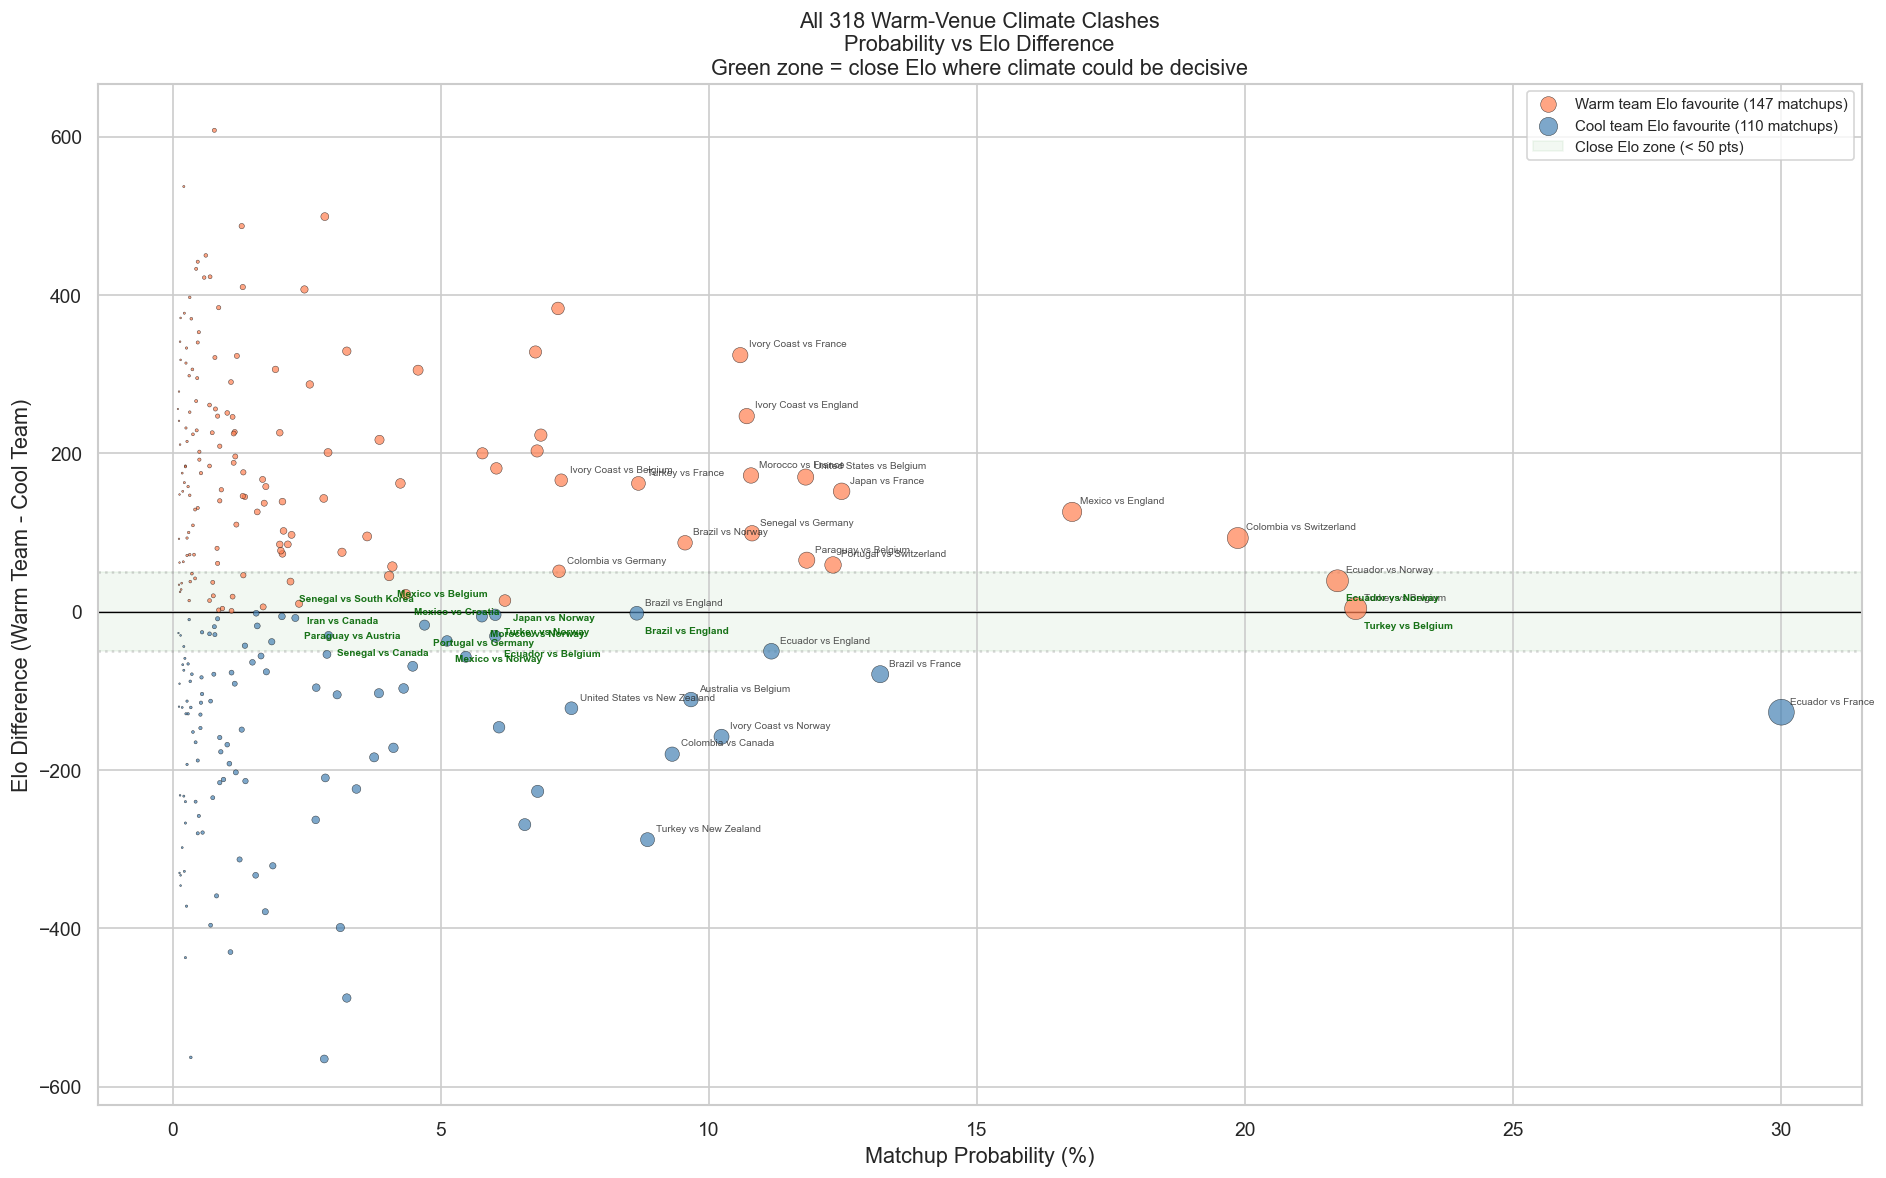

In [10]:
fig, ax = plt.subplots(figsize=(16, 10))

warm_fav = clashes[clashes['Elo_Diff'] > 0]
cool_fav = clashes[clashes['Elo_Diff'] <= 0]

warm_label = 'Warm team Elo favourite (' + str(len(warm_fav)) + ' matchups)'
cool_label = 'Cool team Elo favourite (' + str(len(cool_fav)) + ' matchups)'

ax.scatter(warm_fav['Prob_Pct'], warm_fav['Elo_Diff'],
           c='coral', s=warm_fav['Prob_Pct'] * 8, alpha=0.7,
           edgecolors='black', linewidth=0.3, zorder=3, label=warm_label)

ax.scatter(cool_fav['Prob_Pct'], cool_fav['Elo_Diff'],
           c='steelblue', s=cool_fav['Prob_Pct'] * 8, alpha=0.7,
           edgecolors='black', linewidth=0.3, zorder=3, label=cool_label)

# Annotate top 25 by probability
top = clashes.nlargest(25, 'Prob_Pct')
for _, r in top.iterrows():
    ax.annotate(r['Warm_Team'] + ' vs ' + r['Cool_Team'],
                (r['Prob_Pct'], r['Elo_Diff']),
                textcoords='offset points', xytext=(5, 5), fontsize=6, alpha=0.8)

# Annotate close-Elo matchups in green
close = clashes[clashes['Abs_Elo_Diff'] < 50].nlargest(15, 'Prob_Pct')
for _, r in close.iterrows():
    ax.annotate(r['Warm_Team'] + ' vs ' + r['Cool_Team'],
                (r['Prob_Pct'], r['Elo_Diff']),
                textcoords='offset points', xytext=(5, -12), fontsize=6, alpha=0.9,
                color='darkgreen', fontweight='bold')

ax.axhline(y=0, color='black', linewidth=0.8)
ax.axhline(y=50, color='gray', linestyle=':', alpha=0.3)
ax.axhline(y=-50, color='gray', linestyle=':', alpha=0.3)
ax.axhspan(-50, 50, alpha=0.05, color='green', zorder=0, label='Close Elo zone (< 50 pts)')

ax.set_xlabel('Matchup Probability (%)', fontsize=13)
ax.set_ylabel('Elo Difference (Warm Team - Cool Team)', fontsize=13)
ax.set_title('All 318 Warm-Venue Climate Clashes\nProbability vs Elo Difference\nGreen zone = close Elo where climate could be decisive', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()


## 10. Close-Elo Focus: Where Climate Could Tip the Balance

Matchups with Elo difference < 50 points in warm venues. These are the tossups.


Close-Elo warm-venue climate clashes: 46

  Turkey               vs Belgium                22.1%  Elo diff:   +4  fav: Turkey
  Ecuador              vs Norway                 21.7%  Elo diff:  +39  fav: Ecuador
  Brazil               vs England                 8.7%  Elo diff:   -2  fav: England
  Japan                vs Norway                  6.2%  Elo diff:  +14  fav: Japan
  Ecuador              vs Belgium                 6.0%  Elo diff:  -31  fav: Belgium
  Turkey               vs Norway                  6.0%  Elo diff:   -4  fav: Norway
  Morocco              vs Norway                  5.8%  Elo diff:   -6  fav: Norway
  Mexico               vs Norway                  5.1%  Elo diff:  -37  fav: Norway
  Portugal             vs Germany                 4.7%  Elo diff:  -17  fav: Germany
  Mexico               vs Croatia                 4.3%  Elo diff:  +22  fav: Mexico
  Mexico               vs Belgium                 4.0%  Elo diff:  +45  fav: Mexico
  Senegal              vs Canad

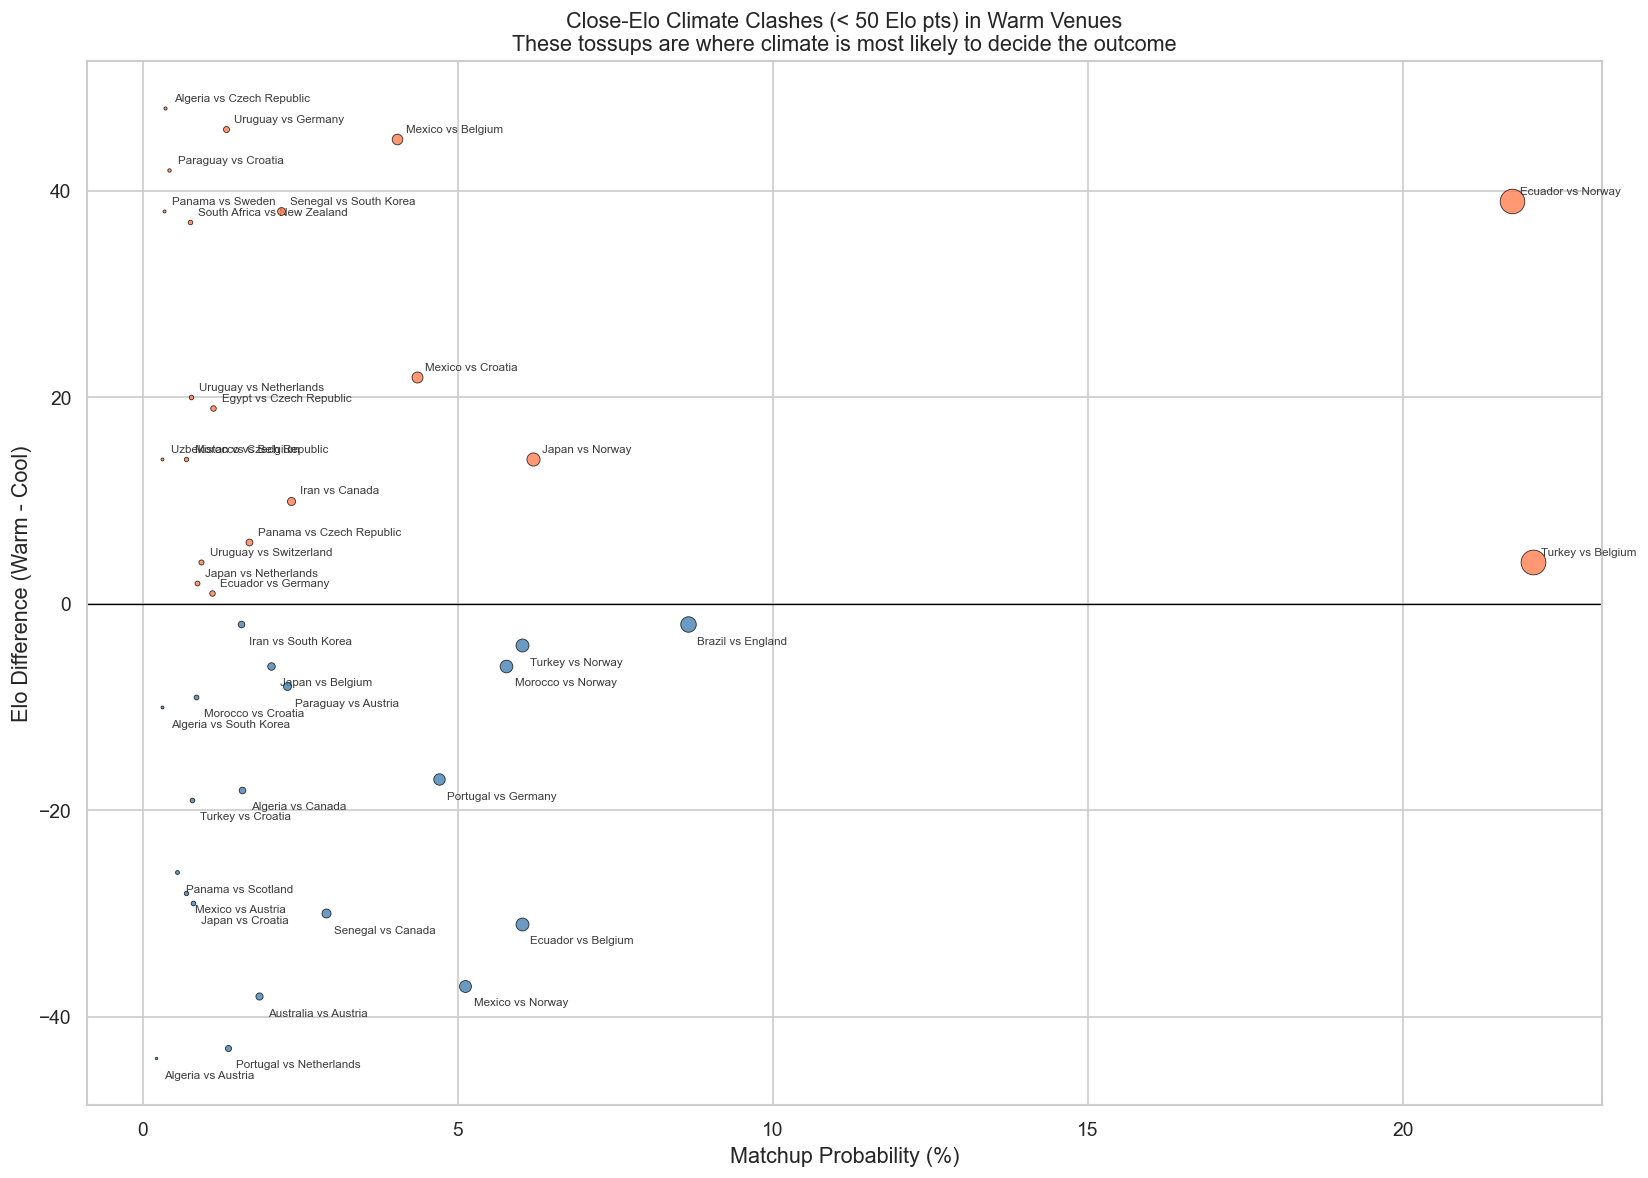

In [11]:
close_elo = clashes[clashes['Abs_Elo_Diff'] < 50].nlargest(40, 'Prob_Pct')

fig, ax = plt.subplots(figsize=(14, 10))

for _, r in close_elo.iterrows():
    c = 'coral' if r['Elo_Diff'] > 0 else 'steelblue'
    ax.scatter(r['Prob_Pct'], r['Elo_Diff'], c=c, s=r['Prob_Pct'] * 10,
              alpha=0.8, edgecolors='black', linewidth=0.5, zorder=5)
    ax.annotate(r['Warm_Team'] + ' vs ' + r['Cool_Team'],
                (r['Prob_Pct'], r['Elo_Diff']),
                textcoords='offset points',
                xytext=(5, 4 if r['Elo_Diff'] > 0 else -12),
                fontsize=7, alpha=0.9)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xlabel('Matchup Probability (%)', fontsize=13)
ax.set_ylabel('Elo Difference (Warm - Cool)', fontsize=13)
ax.set_title('Close-Elo Climate Clashes (< 50 Elo pts) in Warm Venues\nThese tossups are where climate is most likely to decide the outcome', fontsize=13)
plt.tight_layout()

total_close = len(clashes[clashes['Abs_Elo_Diff'] < 50])
print(f'Close-Elo warm-venue climate clashes: {total_close}')
print()
for _, r in close_elo.head(20).iterrows():
    fav = r['Warm_Team'] if r['Elo_Diff'] > 0 else r['Cool_Team']
    print(f'  {r["Warm_Team"]:<20} vs {r["Cool_Team"]:<20}  {r["Prob_Pct"]:5.1f}%  Elo diff: {r["Elo_Diff"]:+4.0f}  fav: {fav}')
